In [ ]:
"""
Single-digit CNN for gas-meter reading recognition -- following the paper's
actual approach (Son, Park, Lee, Paik, 2019, IEIE Trans. Smart Processing &
Computing):

    1. Digit segmentation: split a 5-digit meter crop into 5 individual
       single-digit images (paper uses connected-component labeling for the
       meter-reading area and MSER for the ID area; this script implements a
       connected-component segmenter as a general-purpose stand-in for both).
    2. Number recognition: ONE CNN classifier with a single 10-way softmax
       output, applied separately to each segmented digit crop.

Honesty note: the paper's segmentation stage includes filtering (bilateral +
morphology), "exception processing," box-size filtering, a rescale step, and
non-maximum suppression -- with specific thresholds that are not published in
the paper's text. What's implemented below is a reasonable, inspectable
connected-component segmenter, NOT a verified reproduction of their exact
pipeline. Use `debug_show_segmentation()` on real samples from your dataset
before trusting it, and tune the constants under "SEGMENTATION CONFIG" if it
misses or merges digits on your images.

This replaces the previous 5-output-head model (gas_meter_cnn.py). If your
data_set_generator produces images where the 5 digits are touching, very
low-contrast, or rotated, connected-component segmentation will need real
tuning -- that's expected; it's exactly the problem the paper spent effort on.
"""

In [1]:


import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [2]:


# ========================= CONFIG =========================
NUM_DIGITS = 5
NUM_CLASSES = 10          # digits 0-9
DIGIT_HEIGHT = 32         # size each segmented single-digit crop is resized to
DIGIT_WIDTH = 32
BATCH_SIZE = 32
EPOCHS = 100

# ---- SEGMENTATION CONFIG (tune against your real images) ----
MIN_COMPONENT_AREA_FRAC = 0.01   # component must cover at least 1% of crop area to count as a digit
MAX_COMPONENT_AREA_FRAC = 0.60   # discard components that are implausibly large (merged digits / background)
BOX_PADDING_PX = 2               # padding added around each detected digit box before crop+resize


In [4]:

# ========================= PATHS =========================
NOTEBOOK_DIR = os.path.abspath("")
BASE_DIR = os.path.abspath(os.path.join(NOTEBOOK_DIR, "..", "data_set_generator_for_cnns_only", "data_set"))

TRAIN_IMG_DIR = os.path.join(BASE_DIR, "train")
VALID_IMG_DIR = os.path.join(BASE_DIR, "valid")
TEST_IMG_DIR = os.path.join(BASE_DIR, "test")

TRAIN_CSV = os.path.join(BASE_DIR, "train.csv")
VALID_CSV = os.path.join(BASE_DIR, "valid.csv")
TEST_CSV = os.path.join(BASE_DIR, "test.csv")


print("Checking paths...")
print(f"Train CSV exists: {os.path.exists(TRAIN_CSV)}")
print(f"Train Image Directory exists: {os.path.exists(TRAIN_IMG_DIR)}")
print(f"Valid CSV exists: {os.path.exists(VALID_CSV)}")
print(f"Valid Image Directory exists: {os.path.exists(VALID_IMG_DIR)}")
print(f"Test CSV exists: {os.path.exists(TEST_CSV)}")
print(f"Test Image Directory exists: {os.path.exists(TEST_IMG_DIR)}")

Checking paths...
Train CSV exists: True
Train Image Directory exists: True
Valid CSV exists: True
Valid Image Directory exists: True
Test CSV exists: True
Test Image Directory exists: True


In [5]:
# ========================= CSV CLEANING =========================
def clean_csv_by_removing_missing_images(csv_path, img_dir, split_name="Dataset"):
    print(f"=== Cleaning {split_name.upper()} Split ===")
    if not os.path.exists(csv_path):
        print(f"Skipping {split_name}: CSV file does not exist at {csv_path}\n")
        return
    if not os.path.exists(img_dir):
        print(f"Skipping {split_name}: Image directory does not exist at {img_dir}\n")
        return

    df = pd.read_csv(csv_path)
    original_row_count = len(df)
    image_exists_mask = df['image'].apply(lambda x: os.path.exists(os.path.join(img_dir, str(x))))
    cleaned_df = df[image_exists_mask]
    removed_rows_count = original_row_count - len(cleaned_df)
    cleaned_df.to_csv(csv_path, index=False)

    print(f"Original rows in CSV: {original_row_count}")
    print(f"Removed {removed_rows_count} rows because their images were missing.")
    print(f"Saved cleaned CSV with {len(cleaned_df)} remaining rows.")
    print("-" * 40 + "\n")


clean_csv_by_removing_missing_images(TRAIN_CSV, TRAIN_IMG_DIR, "Train")
clean_csv_by_removing_missing_images(VALID_CSV, VALID_IMG_DIR, "Validation")
clean_csv_by_removing_missing_images(TEST_CSV, TEST_IMG_DIR, "Test")


=== Cleaning TRAIN Split ===
Original rows in CSV: 1270
Removed 0 rows because their images were missing.
Saved cleaned CSV with 1270 remaining rows.
----------------------------------------

=== Cleaning VALIDATION Split ===
Original rows in CSV: 173
Removed 0 rows because their images were missing.
Saved cleaned CSV with 173 remaining rows.
----------------------------------------

=== Cleaning TEST Split ===
Original rows in CSV: 212
Removed 0 rows because their images were missing.
Saved cleaned CSV with 212 remaining rows.
----------------------------------------



In [6]:





# ========================= LOAD DATA (FAIL-SAFE) =========================
print("Loading datasets safely...")
df_train = pd.read_csv(TRAIN_CSV)
df_valid = pd.read_csv(VALID_CSV)
df_test = pd.read_csv(TEST_CSV)

for name, df, img_dir in [("train", df_train, TRAIN_IMG_DIR),
                           ("valid", df_valid, VALID_IMG_DIR),
                           ("test", df_test, TEST_IMG_DIR)]:
    mask = df['image'].apply(lambda x: os.path.exists(os.path.join(img_dir, str(x))))
    missing = len(df) - mask.sum()
    if missing > 0:
        print(f"Warning: {missing} rows in {name}.csv don't have matching files on disk. Skipping them.")

df_train = df_train[df_train['image'].apply(lambda x: os.path.exists(os.path.join(TRAIN_IMG_DIR, str(x))))]
df_valid = df_valid[df_valid['image'].apply(lambda x: os.path.exists(os.path.join(VALID_IMG_DIR, str(x))))]
df_test = df_test[df_test['image'].apply(lambda x: os.path.exists(os.path.join(TEST_IMG_DIR, str(x))))]

df_train['label'] = df_train['label'].astype(int)
df_valid['label'] = df_valid['label'].astype(int)
df_test['label'] = df_test['label'].astype(int)

print(f"\nFinal Ready Samples -> Train: {len(df_train)} | Val: {len(df_valid)} | Test: {len(df_test)}")


Loading datasets safely...

Final Ready Samples -> Train: 1270 | Val: 173 | Test: 212


In [7]:

# ========================= DIGIT SEGMENTATION =========================
def _binarize_for_segmentation(gray_img):
    """Denoise + threshold so digit strokes end up as white (255) on a
    black (0) background, regardless of the original polarity."""
    denoised = cv2.bilateralFilter(gray_img, d=5, sigmaColor=50, sigmaSpace=50)
    _, binary = cv2.threshold(denoised, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Otsu doesn't know which side is "foreground". Assume digit strokes are
    # the minority of pixels (true for most meter/ID crops); if white pixels
    # are the majority, the polarity is inverted, so flip it.
    if np.mean(binary == 255) > 0.5:
        binary = cv2.bitwise_not(binary)

    # Morphological close to bridge small gaps within a single digit's strokes.
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
    return binary


In [8]:
def segment_digit_boxes(gray_img, num_digits=NUM_DIGITS):
    """Returns a list of `num_digits` (x, y, w, h) boxes, left-to-right,
    one per digit. Falls back to equal-width slicing if connected-component
    analysis doesn't cleanly find `num_digits` plausible components --
    this fallback is a safety net, not a substitute for correct segmentation;
    check debug_show_segmentation() on real samples to see how often it fires."""
    h_img, w_img = gray_img.shape[:2]
    img_area = h_img * w_img

    binary = _binarize_for_segmentation(gray_img)
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary, connectivity=8)

    boxes = []
    for label_id in range(1, num_labels):  # skip background label 0
        x, y, w, h, area = stats[label_id]
        area_frac = area / img_area
        if MIN_COMPONENT_AREA_FRAC <= area_frac <= MAX_COMPONENT_AREA_FRAC:
            boxes.append((x, y, w, h))

    if len(boxes) == num_digits:
        boxes.sort(key=lambda b: b[0])  # left-to-right
        return boxes

    if len(boxes) > num_digits:
        # Keep the `num_digits` largest-area components, then re-sort by x.
        boxes.sort(key=lambda b: b[2] * b[3], reverse=True)
        boxes = boxes[:num_digits]
        boxes.sort(key=lambda b: b[0])
        return boxes

    # Fallback: connected components didn't find enough plausible digits
    # (e.g. touching digits, low contrast). Slice the crop into num_digits
    # equal-width columns instead. This is a crude fallback -- if it fires
    # often on your data, the segmentation constants above need tuning.
    col_width = w_img / num_digits
    return [(int(i * col_width), 0, int(col_width), h_img) for i in range(num_digits)]

In [9]:
def extract_digit_crops(gray_img, num_digits=NUM_DIGITS,
                         target_size=(DIGIT_HEIGHT, DIGIT_WIDTH)):
    """Segments gray_img into num_digits single-digit crops, each resized to
    target_size and normalized to [0, 1], shape (H, W, 1)."""
    h_img, w_img = gray_img.shape[:2]
    boxes = segment_digit_boxes(gray_img, num_digits=num_digits)

    crops = []
    for (x, y, w, h) in boxes:
        x0 = max(0, x - BOX_PADDING_PX)
        y0 = max(0, y - BOX_PADDING_PX)
        x1 = min(w_img, x + w + BOX_PADDING_PX)
        y1 = min(h_img, y + h + BOX_PADDING_PX)

        crop = gray_img[y0:y1, x0:x1]
        if crop.size == 0:
            crop = np.zeros((target_size[0], target_size[1]), dtype=np.uint8)

        crop = cv2.resize(crop, (target_size[1], target_size[0]))
        crop = crop.astype(np.float32) / 255.0
        crops.append(np.expand_dims(crop, axis=-1))

    return crops


In [10]:

def debug_show_segmentation(image_path, num_digits=NUM_DIGITS):
    """Visualize segmentation boxes + the resulting crops for one image.
    Run this on a handful of real samples before training, to sanity-check
    that segmentation is actually cutting individual digits correctly."""
    gray_img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    boxes = segment_digit_boxes(gray_img, num_digits=num_digits)
    crops = extract_digit_crops(gray_img, num_digits=num_digits)

    fig, axes = plt.subplots(1, num_digits + 1, figsize=(3 * (num_digits + 1), 3))

    boxed_img = cv2.cvtColor(gray_img, cv2.COLOR_GRAY2BGR)
    for (x, y, w, h) in boxes:
        cv2.rectangle(boxed_img, (x, y), (x + w, y + h), (0, 255, 0), 1)
    axes[0].imshow(boxed_img)
    axes[0].set_title("Detected boxes")
    axes[0].axis('off')

    for i, crop in enumerate(crops):
        axes[i + 1].imshow(crop.squeeze(), cmap='gray')
        axes[i + 1].set_title(f"digit slot {i+1}")
        axes[i + 1].axis('off')

    plt.tight_layout()
    plt.show()


In [11]:
# ========================= BUILD PER-DIGIT DATASETS =========================
def build_digit_dataset(df, img_dir, num_digits=NUM_DIGITS):
    """Runs segmentation over every row in df and returns:
        X: float32 array of shape (N * num_digits, H, W, 1)
        y: int array of shape (N * num_digits,)          -- single digit labels
        group_ids: int array of shape (N * num_digits,)  -- which original
                   row each crop came from, so full-number accuracy can be
                   reconstructed later (crops from the same row are adjacent
                   and in left-to-right digit order).
    """
    X, y, group_ids = [], [], []

    for group_id, (_, row) in enumerate(df.iterrows()):
        img_path = os.path.join(img_dir, str(row['image']))
        gray_img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if gray_img is None:
            continue

        padded_label = str(int(row['label'])).zfill(num_digits)
        crops = extract_digit_crops(gray_img, num_digits=num_digits)

        for digit_char, crop in zip(padded_label, crops):
            X.append(crop)
            y.append(int(digit_char))
            group_ids.append(group_id)

    X = np.stack(X, axis=0).astype(np.float32)
    y = np.array(y, dtype=np.int64)
    group_ids = np.array(group_ids, dtype=np.int64)
    return X, y, group_ids


print("Segmenting training images into individual digits...")
X_train, y_train, _ = build_digit_dataset(df_train, TRAIN_IMG_DIR)
print(f"Train digit crops: {X_train.shape[0]}")

print("Segmenting validation images into individual digits...")
X_valid, y_valid, _ = build_digit_dataset(df_valid, VALID_IMG_DIR)
print(f"Valid digit crops: {X_valid.shape[0]}")

print("Segmenting test images into individual digits...")
X_test, y_test, test_group_ids = build_digit_dataset(df_test, TEST_IMG_DIR)
print(f"Test digit crops: {X_test.shape[0]}")

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(2048).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((X_valid, y_valid)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


Segmenting training images into individual digits...
Train digit crops: 6350
Segmenting validation images into individual digits...
Valid digit crops: 865
Segmenting test images into individual digits...
Test digit crops: 1060


In [12]:

# ========================= MODEL (single-digit classifier) =========================
def vgg_block(x, filters, block_name):
    """Paired 3x3 convs per block, per the paper's described pattern
    ("3x3 convolution twice, like VGG, but reduces the overall depth")."""
    x = layers.Conv2D(filters, (3, 3), padding='same', name=f'{block_name}_conv1')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(filters, (3, 3), padding='same', name=f'{block_name}_conv2')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)
    return x


def create_single_digit_model():
    inputs = layers.Input(shape=(DIGIT_HEIGHT, DIGIT_WIDTH, 1))

    x = vgg_block(inputs, 32, 'block1')
    x = vgg_block(x, 64, 'block2')

    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    output = layers.Dense(NUM_CLASSES, activation='softmax', name='digit')(x)

    return models.Model(inputs=inputs, outputs=output)


model = create_single_digit_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ digit (Dense)                   │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 591,978 (2.26 MB)

 Trainable params: 591,338 (2.26 MB)

 Non-trainable params: 640 (2.50 KB)

In [13]:

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
]

In [14]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)

Epoch 1/100


c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


199/199 ━━━━━━━━━━━━━━━━━━━━ 38s 158ms/step - accuracy: 0.3239 - loss: 2.2204 - val_accuracy: 0.0613 - val_loss: 2.5531 - learning_rate: 0.0010
Epoch 2/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 30s 151ms/step - accuracy: 0.4772 - loss: 1.6519 - val_accuracy: 0.2798 - val_loss: 2.1628 - learning_rate: 0.0010
Epoch 3/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 34s 170ms/step - accuracy: 0.5365 - loss: 1.4875 - val_accuracy: 0.1029 - val_loss: 5.0813 - learning_rate: 0.0010
Epoch 4/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 33s 164ms/step - accuracy: 0.5831 - loss: 1.3465 - val_accuracy: 0.6162 - val_loss: 1.3123 - learning_rate: 0.0010
Epoch 5/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 31s 157ms/step - accuracy: 0.6231 - loss: 1.2595 - val_accuracy: 0.6393 - val_loss: 1.2433 - learning_rate: 0.0010
Epoch 6/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 28s 139ms/step - accuracy: 0.6702 - loss: 1.1439 - val_accuracy: 0.5977 - val_loss: 1.2670 - learning_rate: 0.0010
Epoch 7/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 32s 160ms/step - accuracy: 0.6817 -

In [15]:
# ========================= EVALUATION (paper-style reporting) =========================
def evaluate_full():
    """Per-digit accuracy (like the paper's Table 3/4) AND full-5-digit
    exact-match accuracy reconstructed from grouped crops (like Table 5)."""
    preds = model.predict(X_test, verbose=0)
    pred_labels = np.argmax(preds, axis=1)

    per_digit_acc = np.mean(pred_labels == y_test)
    print(f"\nSingle-digit accuracy across all positions: {per_digit_acc * 100:.2f}%")

    # per-class (0-9) breakdown, mirroring the paper's per-digit-value tables
    for digit_class in range(NUM_CLASSES):
        class_mask = y_test == digit_class
        if class_mask.sum() == 0:
            continue
        class_acc = np.mean(pred_labels[class_mask] == digit_class)
        print(f"  class {digit_class}: {class_mask.sum()} samples, accuracy {class_acc * 100:.2f}%")

    # Reconstruct full-number exact match using group_ids (5 consecutive
    # crops per original image, already in left-to-right order).
    num_groups = test_group_ids.max() + 1
    exact_matches = 0
    for g in range(num_groups):
        idx = np.where(test_group_ids == g)[0]
        if len(idx) != NUM_DIGITS:
            continue  # skip incomplete groups (shouldn't normally happen)
        if np.array_equal(pred_labels[idx], y_test[idx]):
            exact_matches += 1
    exact_match_acc = exact_matches / num_groups
    print(f"Full 5-digit exact-match accuracy: {exact_match_acc * 100:.2f}%")

    return per_digit_acc, exact_match_acc


evaluate_full()


Single-digit accuracy across all positions: 73.77%
  class 0: 326 samples, accuracy 93.25%
  class 1: 91 samples, accuracy 76.92%
  class 2: 112 samples, accuracy 66.96%
  class 3: 90 samples, accuracy 67.78%
  class 4: 72 samples, accuracy 70.83%
  class 5: 89 samples, accuracy 68.54%
  class 6: 64 samples, accuracy 46.88%
  class 7: 70 samples, accuracy 58.57%
  class 8: 73 samples, accuracy 68.49%
  class 9: 73 samples, accuracy 53.42%
Full 5-digit exact-match accuracy: 40.57%


(np.float64(0.7377358490566037), np.float64(0.4056603773584906))

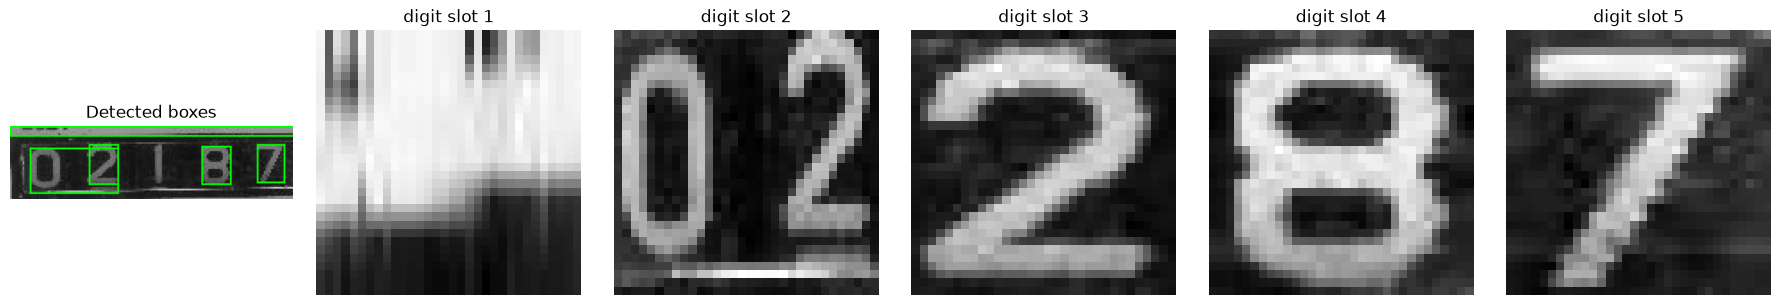

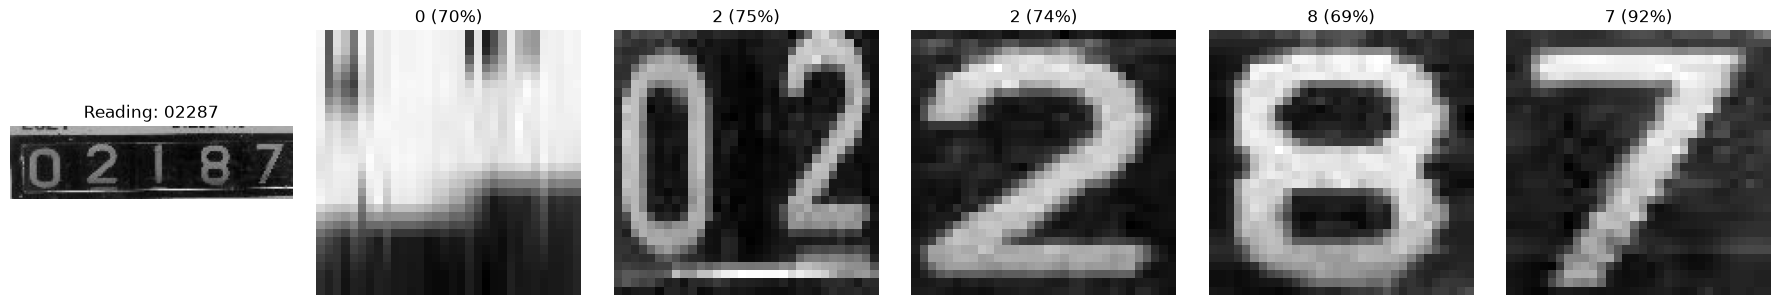

('02287',
 array([70.05732 , 74.68296 , 73.905106, 68.65982 , 92.05257 ],
       dtype=float32))

In [28]:



# ========================= FULL METER-READING INFERENCE =========================
def read_meter(image_path, num_digits=NUM_DIGITS):
    """Runs the full paper-style pipeline on one image: segment into
    num_digits crops, classify each crop independently with the single
    shared model, concatenate into the final reading."""
    gray_img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if gray_img is None:
        raise FileNotFoundError(f"Missing file: {image_path}")

    crops = extract_digit_crops(gray_img, num_digits=num_digits)
    batch = np.stack(crops, axis=0)  # (num_digits, H, W, 1) -- one batched call, not 5 separate ones

    preds = model.predict(batch, verbose=0)
    digit_predictions = np.argmax(preds, axis=1)
    confidences = np.max(preds, axis=1) * 100

    final_reading = "".join(str(d) for d in digit_predictions)

    fig, axes = plt.subplots(1, num_digits + 1, figsize=(3 * (num_digits + 1), 3))
    axes[0].imshow(gray_img, cmap='gray')
    axes[0].set_title(f"Reading: {final_reading}")
    axes[0].axis('off')

    for i, crop in enumerate(crops):
        axes[i + 1].imshow(crop.squeeze(), cmap='gray')
        axes[i + 1].set_title(f"{digit_predictions[i]} ({confidences[i]:.0f}%)")
        axes[i + 1].axis('off')

    plt.tight_layout()
    plt.show()

    return final_reading, confidences


# Example usage:
debug_show_segmentation(os.path.join(TEST_IMG_DIR, "74683849983_crop_0.png"))  # check segmentation first
read_meter(os.path.join(TEST_IMG_DIR, "74683849983_crop_0.png"))



In [ ]:

# ========================= SAVE =========================
model.save("single_digit_model_final.keras")
print("Training completed and model saved.")